In [10]:
# Collect or download a weather dataset from Kaggle or online sources.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
from google.colab import files

uploaded = files.upload()

Saving india_2000_2024_daily_weather_cleaned.csv to india_2000_2024_daily_weather_cleaned (1).csv


In [12]:
df = pd.read_csv("india_2000_2024_daily_weather_cleaned.csv")

df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,precipitation_sum,rain_sum,weather_code,wind_speed_10m_max,wind_gusts_10m_max,wind_direction_10m_dominant
0,Ahmedabad,2000-01-01,29.9,15.3,29.1,12.8,0.0,0.0,0,14.5,30.2,60
1,Ahmedabad,2000-01-02,29.9,16.1,28.8,13.2,0.0,0.0,0,15.3,29.5,68
2,Ahmedabad,2000-01-03,29.1,15.1,27.9,12.1,0.0,0.0,0,14.4,27.7,52
3,Ahmedabad,2000-01-04,28.6,13.7,27.5,11.2,0.0,0.0,0,12.4,21.6,45
4,Ahmedabad,2000-01-05,28.1,13.2,26.8,10.8,0.0,0.0,0,11.3,22.7,34


In [13]:
df.shape

(91320, 12)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   city                         91320 non-null  object 
 1   date                         91320 non-null  object 
 2   temperature_2m_max           91320 non-null  float64
 3   temperature_2m_min           91320 non-null  float64
 4   apparent_temperature_max     91320 non-null  float64
 5   apparent_temperature_min     91320 non-null  float64
 6   precipitation_sum            91320 non-null  float64
 7   rain_sum                     91320 non-null  float64
 8   weather_code                 91320 non-null  int64  
 9   wind_speed_10m_max           91320 non-null  float64
 10  wind_gusts_10m_max           91320 non-null  float64
 11  wind_direction_10m_dominant  91320 non-null  int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 8.4+ MB


In [15]:
df.isnull().sum()

,0
city,0
date,0
temperature_2m_max,0
temperature_2m_min,0
apparent_temperature_max,0
apparent_temperature_min,0
precipitation_sum,0
rain_sum,0
weather_code,0
wind_speed_10m_max,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df["date"] = pd.to_datetime(df["date"])

In [18]:
# Load and clean the dataset using Pandas.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91320 entries, 0 to 91319
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   city                         91320 non-null  object        
 1   date                         91320 non-null  datetime64[ns]
 2   temperature_2m_max           91320 non-null  float64       
 3   temperature_2m_min           91320 non-null  float64       
 4   apparent_temperature_max     91320 non-null  float64       
 5   apparent_temperature_min     91320 non-null  float64       
 6   precipitation_sum            91320 non-null  float64       
 7   rain_sum                     91320 non-null  float64       
 8   weather_code                 91320 non-null  int64         
 9   wind_speed_10m_max           91320 non-null  float64       
 10  wind_gusts_10m_max           91320 non-null  float64       
 11  wind_direction_10m_dominant  91320 non-nu

In [19]:
df.isnull().sum()

,0
city,0
date,0
temperature_2m_max,0
temperature_2m_min,0
apparent_temperature_max,0
apparent_temperature_min,0
precipitation_sum,0
rain_sum,0
weather_code,0
wind_speed_10m_max,0


In [20]:
#Handle missing values and incorrect records.
df.isnull().sum()

,0
city,0
date,0
temperature_2m_max,0
temperature_2m_min,0
apparent_temperature_max,0
apparent_temperature_min,0
precipitation_sum,0
rain_sum,0
weather_code,0
wind_speed_10m_max,0


In [21]:
(df["temperature_2m_max"] < df["temperature_2m_min"]).sum()

np.int64(0)

In [22]:
(df["rain_sum"] < 0).sum()

np.int64(0)

In [23]:
(df["precipitation_sum"] < 0).sum()

np.int64(0)

In [24]:
# Analyze temperature, rainfall, and humidity trends
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [25]:
df[["date", "year", "month"]].head()

,date,year,month
0,2000-01-01,2000,1
1,2000-01-02,2000,1
2,2000-01-03,2000,1
3,2000-01-04,2000,1
4,2000-01-05,2000,1


In [26]:
temperature_trend = df.groupby("year")[[
    "temperature_2m_max",
    "temperature_2m_min"
]].mean()

temperature_trend.head()

,temperature_2m_max,temperature_2m_min
year,,
2000,30.725137,20.658962
2001,30.748329,20.815370
2002,31.334548,21.170356
2003,30.821260,20.938849
2004,30.899016,20.916721


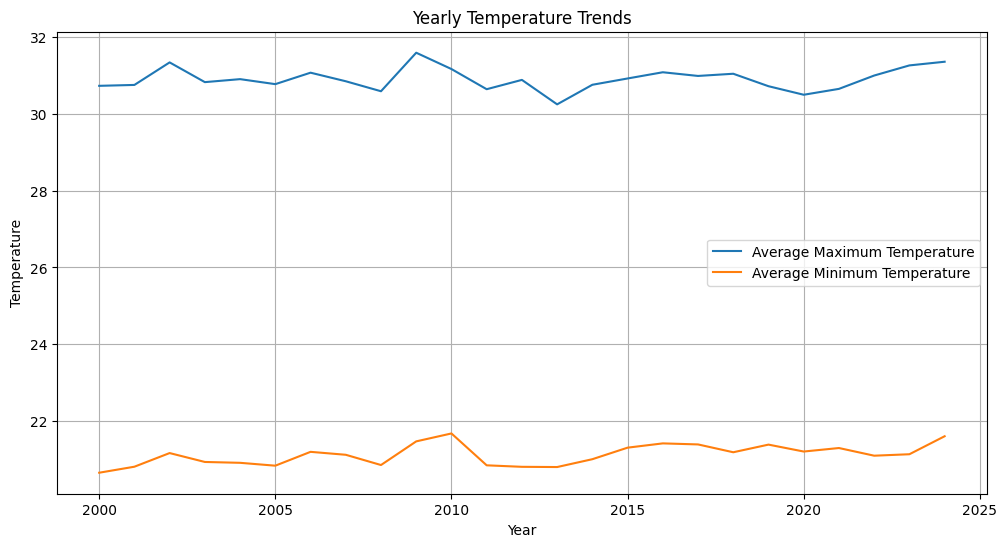

In [27]:
plt.figure(figsize=(12, 6))

plt.plot(
    temperature_trend.index,
    temperature_trend["temperature_2m_max"],
    label="Average Maximum Temperature"
)

plt.plot(
    temperature_trend.index,
    temperature_trend["temperature_2m_min"],
    label="Average Minimum Temperature"
)

plt.xlabel("Year")
plt.ylabel("Temperature")
plt.title("Yearly Temperature Trends")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
rainfall_trend = df.groupby("year")["rain_sum"].mean()

rainfall_trend.head()

,rain_sum
year,
2000,2.576940
2001,2.712027
2002,2.212192
2003,2.805534
2004,2.840519


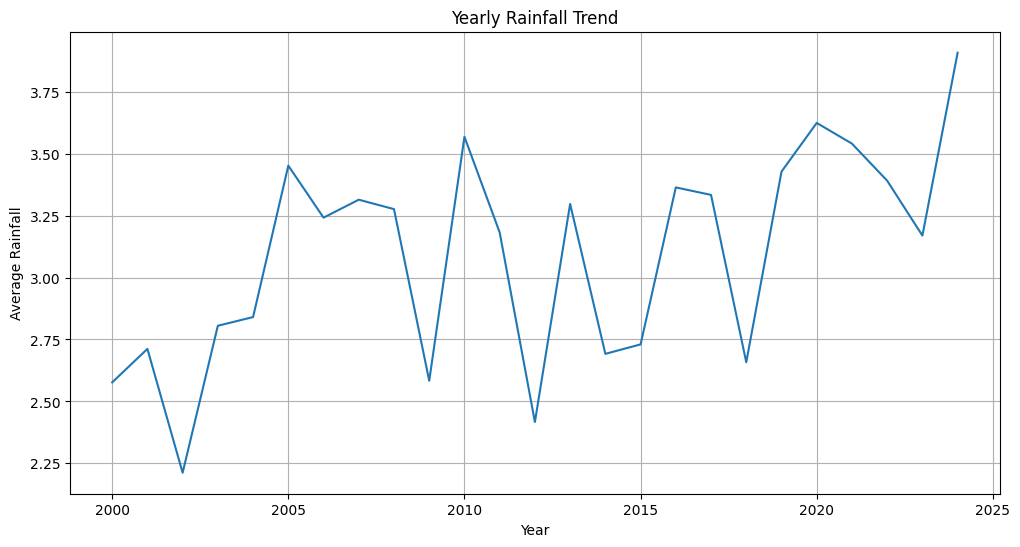

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    rainfall_trend.index,
    rainfall_trend.values
)

plt.xlabel("Year")
plt.ylabel("Average Rainfall")
plt.title("Yearly Rainfall Trend")
plt.grid(True)

plt.show()

In [30]:
monthly_temperature = df.groupby("month")[
    ["temperature_2m_max", "temperature_2m_min"]
].mean()

monthly_temperature

,temperature_2m_max,temperature_2m_min
month,,
1,25.713316,14.057871
2,28.668161,16.109307
3,32.699600,19.720671
4,36.046280,23.441120
5,36.752916,25.745535
6,33.952613,26.100160
7,30.641574,24.958000
8,29.897110,24.359794
9,30.347667,23.724640


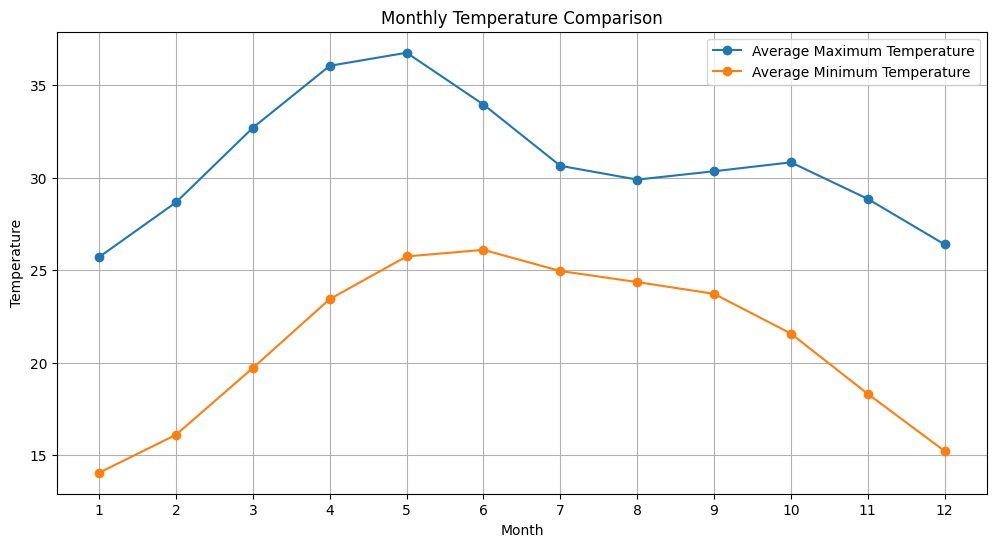

In [31]:
# Generate business insights and recommendations
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_temperature.index,
    monthly_temperature["temperature_2m_max"],
    marker="o",
    label="Average Maximum Temperature"
)

plt.plot(
    monthly_temperature.index,
    monthly_temperature["temperature_2m_min"],
    marker="o",
    label="Average Minimum Temperature"
)

plt.xlabel("Month")
plt.ylabel("Temperature")
plt.title("Monthly Temperature Comparison")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True)

plt.show()


In [32]:
monthly_rainfall = df.groupby("month")["rain_sum"].mean()

monthly_rainfall

,rain_sum
month,
1,0.326503
2,0.356464
3,0.414387
4,0.555707
5,1.396490
6,5.359547
7,9.693316
8,7.987639
9,5.873773


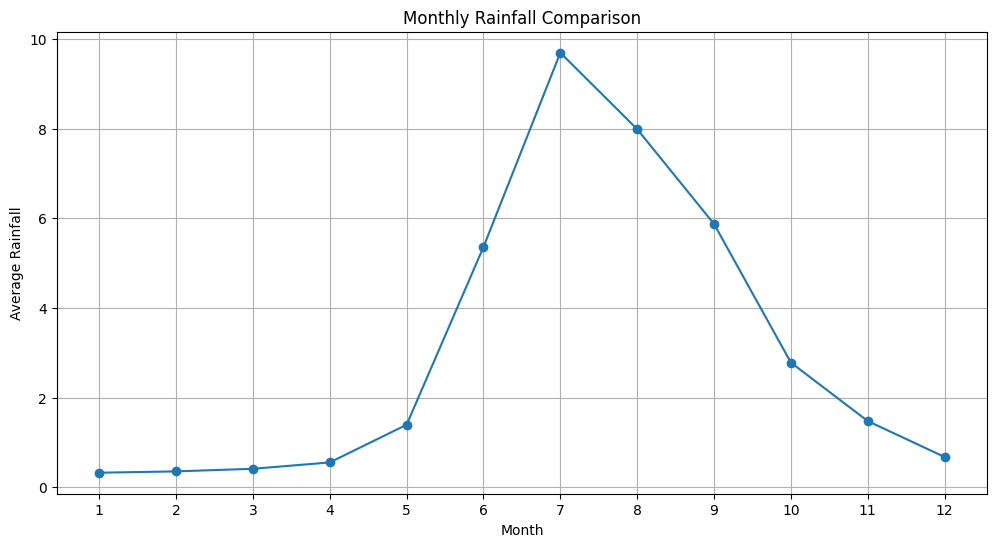

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_rainfall.index,
    monthly_rainfall.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Rainfall")
plt.title("Monthly Rainfall Comparison")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

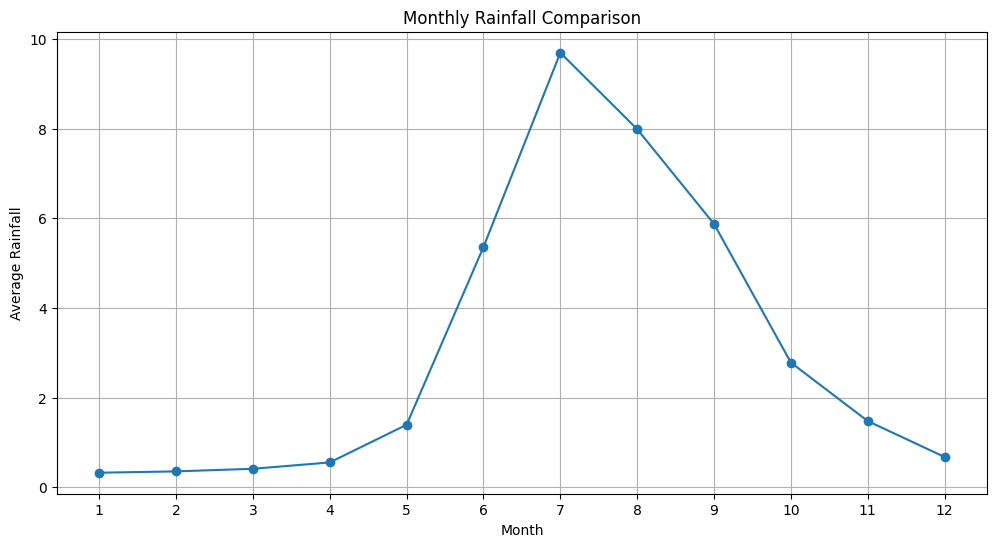

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_rainfall.index,
    monthly_rainfall.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average Rainfall")
plt.title("Monthly Rainfall Comparison")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

In [ ]:
'''
#Prepare a detailed analysis report.

# Weather Data Analysis – Insights Report

## 1. Project Overview

This project analyzes daily weather data from **2000 to 2024** using Python and Pandas. The analysis focuses on temperature and rainfall trends and compares weather conditions across different months.

## 2. Data Cleaning

The dataset was checked and cleaned before performing the analysis.

- Dataset contains **91,320 records and 12 columns**.
- The `date` column was converted into datetime format.
- No missing values were found.
- No duplicate records were found.
- No incorrect temperature records were found where maximum temperature was lower than minimum temperature.
- No negative rainfall or precipitation values were found.

## 3. Temperature Insights

- Year-wise average maximum and minimum temperatures were analyzed from **2000 to 2024**.
- Monthly temperature analysis shows a clear seasonal pattern.
- **May** recorded the highest average maximum temperature: **36.75**.
- **January** recorded the lowest average minimum temperature: **14.06**.

## 4. Rainfall Insights

- Year-wise average rainfall was analyzed for the period **2000–2024**.
- Monthly rainfall shows a strong seasonal variation.
- **July** recorded the highest average rainfall: **9.69**.
- **January** recorded the lowest average rainfall: **0.33**.

## 5. Humidity

The provided dataset does **not contain a humidity column**. Therefore, humidity trends could not be analyzed from this dataset. No humidity values were estimated or created.

## 6. Visualization

The following visualizations were created using **Matplotlib**:

1. Yearly Temperature Trends
2. Yearly Rainfall Trend
3. Monthly Temperature Comparison
4. Monthly Rainfall Comparison

## 7. Conclusion

The analysis shows clear seasonal variations in temperature and rainfall. Temperatures generally increase toward the warmer months, while rainfall is considerably higher during the middle months of the year. **July has the highest average rainfall, while May has the highest average maximum temperature** in the analyzed dataset.

### Tools Used

Python, Pandas, NumPy, Matplotlib, Google Colab.

'''